# DSC 291: Learning Theory - PA7

**James Doan**

## Part A: Kernel Methods

### 1. Norm-based kernel bound

**Claim:** The empirical Rademacher bound is $\hat{\mathcal{R}}_S(\mathcal{H}_{K,B}) \le \frac{B}{n} \sqrt{\sum_{i=1}^n K(x_i, x_i)}$.

**Proof:**
By definition, the empirical Rademacher complexity is:
$$ \hat{\mathcal{R}}_S(\mathcal{H}_{K,B}) = \frac{1}{n} \mathbb{E}_{\sigma} \left[ \sup_{\|w\| \le B} \sum_{i=1}^n \sigma_i \langle w, \varphi(x_i) \rangle \right] = \frac{1}{n} \mathbb{E}_{\sigma} \left[ \sup_{\|w\| \le B} \left\langle w, \sum_{i=1}^n \sigma_i \varphi(x_i) \right\rangle \right] $$

By the Cauchy-Schwarz inequality, $\langle w, v \rangle \le \|w\| \|v\|$. The supremum over $\|w\| \le B$ is achieved when $w$ is aligned with the vector sum, yielding $B \|v\|$. Thus:
$$ \hat{\mathcal{R}}_S(\mathcal{H}_{K,B}) = \frac{B}{n} \mathbb{E}_{\sigma} \left[ \left\| \sum_{i=1}^n \sigma_i \varphi(x_i) \right\| \right] $$

Applying Jensen's inequality to the concave square root function:
$$ \hat{\mathcal{R}}_S(\mathcal{H}_{K,B}) \le \frac{B}{n} \sqrt{ \mathbb{E}_{\sigma} \left[ \left\| \sum_{i=1}^n \sigma_i \varphi(x_i) \right\|^2 \right] } $$

Expanding the squared norm using the inner product:
$$ \mathbb{E}_{\sigma} \left[ \left\langle \sum_{i=1}^n \sigma_i \varphi(x_i), \sum_{j=1}^n \sigma_j \varphi(x_j) \right\rangle \right] = \sum_{i=1}^n \sum_{j=1}^n \mathbb{E}_{\sigma}[\sigma_i \sigma_j] \langle \varphi(x_i), \varphi(x_j) \rangle $$

Since $\sigma_i$ are independent uniform signs, $\mathbb{E}[\sigma_i \sigma_j] = 1$ if $i=j$ and $0$ if $i \neq j$. Thus, the cross terms vanish:
$$ \sum_{i=1}^n \langle \varphi(x_i), \varphi(x_i) \rangle = \sum_{i=1}^n K(x_i, x_i) $$

Substituting this back yields the empirical bound:
$$ \hat{\mathcal{R}}_S(\mathcal{H}_{K,B}) \le \frac{B}{n} \sqrt{\sum_{i=1}^n K(x_i, x_i)} $$

---

**Claim:** The distribution-level bound is $\mathcal{R}_{\mathcal{D}}^n(\mathcal{H}_{K,B}) \le B \sqrt{\frac{\mathbb{E}[K(X, X)]}{n}}$.

**Proof:**
Taking the expectation over the sample $S \sim \mathcal{D}^n$:
$$ \mathcal{R}_{\mathcal{D}}^n(\mathcal{H}_{K,B}) = \mathbb{E}_{S} [\hat{\mathcal{R}}_S(\mathcal{H}_{K,B})] \le \mathbb{E}_{S} \left[ \frac{B}{n} \sqrt{\sum_{i=1}^n K(x_i, x_i)} \right] $$

Applying Jensen's inequality again over the expectation of the sample:
$$ \mathcal{R}_{\mathcal{D}}^n(\mathcal{H}_{K,B}) \le \frac{B}{n} \sqrt{ \mathbb{E}_{S} \left[ \sum_{i=1}^n K(x_i, x_i) \right] } $$

By linearity of expectation and since each $x_i$ is identically distributed as $X$, $\mathbb{E}_S[\sum_{i=1}^n K(x_i, x_i)] = n \mathbb{E}[K(X,X)]$. Thus:
$$ \mathcal{R}_{\mathcal{D}}^n(\mathcal{H}_{K,B}) \le \frac{B}{n} \sqrt{n \mathbb{E}[K(X, X)]} = B \sqrt{\frac{\mathbb{E}[K(X, X)]}{n}} $$

### 2. Representer theorem

**Claim:** Any minimizer $w^*$ of $J(w)$ has the form $w^* = \sum_{j=1}^n \alpha_j \varphi(x_j)$.

**Proof:**
Let $S = \text{span}(\{\varphi(x_1), \dots, \varphi(x_n)\})$. By the Orthogonal Projection Theorem for Hilbert spaces, any $w \in \mathcal{U}$ can be uniquely decomposed as $w = w_S + w_\perp$, where $w_S \in S$ and $w_\perp \in S^\perp$ (meaning $\langle w_\perp, \varphi(x_i) \rangle = 0$ for all $i$).

Consider the empirical loss term. The prediction for $x_i$ is:
$$ \langle w, \varphi(x_i) \rangle = \langle w_S + w_\perp, \varphi(x_i) \rangle = \langle w_S, \varphi(x_i) \rangle + \langle w_\perp, \varphi(x_i) \rangle = \langle w_S, \varphi(x_i) \rangle $$
This demonstrates that the empirical loss strictly depends only on $w_S$.

Now consider the regularization term. By the Pythagorean theorem:
$$ \|w\|^2 = \|w_S + w_\perp\|^2 = \|w_S\|^2 + \|w_\perp\|^2 \ge \|w_S\|^2 $$

Since $\lambda > 0$, the objective satisfies $J(w) \ge J(w_S)$, with equality if and only if $\|w_\perp\|^2 = 0 \implies w_\perp = 0$.
Thus, any minimizer $w^*$ must have $w_\perp = 0$, meaning $w^* \in S$. Consequently, it can be expressed as a linear combination of the data points:
$$ w^* = \sum_{j=1}^n \alpha_j \varphi(x_j), \quad \alpha \in \mathbb{R}^n $$

---

**Claim:** $J(w)$ can be rewritten as a minimization over $\alpha \in \mathbb{R}^n$.

**Proof:**
Substituting $w = \sum_{j=1}^n \alpha_j \varphi(x_j)$ into the predictions:
$$ \langle w, \varphi(x_i) \rangle = \left\langle \sum_{j=1}^n \alpha_j \varphi(x_j), \varphi(x_i) \right\rangle = \sum_{j=1}^n \alpha_j K(x_j, x_i) = (K_S \alpha)_i $$

Substituting into the norm:
$$ \|w\|^2 = \left\langle \sum_{i=1}^n \alpha_i \varphi(x_i), \sum_{j=1}^n \alpha_j \varphi(x_j) \right\rangle = \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j K(x_i, x_j) = \alpha^T K_S \alpha $$

Thus, the regularized objective minimization reduces entirely to $\alpha$ and the Gram matrix $K_S$:
$$ \min_{\alpha \in \mathbb{R}^n} J(\alpha) = \frac{1}{n} \sum_{i=1}^n \text{loss}((K_S \alpha)_i; y_i) + \lambda \alpha^T K_S \alpha $$

## Part B: $\ell_1$ Rademacher Complexity

### 1. Convex hulls

**Claim:** Taking the convex hull of a finite function class does not change its empirical Rademacher complexity: $\hat{\mathcal{R}}_S(\text{conv}(\mathcal{F})) = \hat{\mathcal{R}}_S(\mathcal{F})$.

**Proof:**
By definition,
$$ \hat{\mathcal{R}}_S(\text{conv}(\mathcal{F})) = \frac{1}{n} \mathbb{E}_{\sigma} \left[ \sup_{g \in \text{conv}(\mathcal{F})} \sum_{i=1}^n \sigma_i g(x_i) \right] $$

Any function $g \in \text{conv}(\mathcal{F})$ can be written as a convex combination $g(x) = \sum_{f \in \mathcal{F}} a_f f(x)$, where $a_f \ge 0$ and $\sum_{f \in \mathcal{F}} a_f = 1$.
For a fixed sequence of signs $\sigma$, the summation inside the supremum becomes:
$$ \sum_{i=1}^n \sigma_i g(x_i) = \sum_{i=1}^n \sigma_i \left( \sum_{f \in \mathcal{F}} a_f f(x_i) \right) = \sum_{f \in \mathcal{F}} a_f \left( \sum_{i=1}^n \sigma_i f(x_i) \right) $$

We are maximizing a linear function of $a$ over the probability simplex $\Delta_{|\mathcal{F}|}$. The fundamental theorem of linear programming states that the maximum of a linear function over a convex polytope is attained at one of its vertices. The vertices of this simplex correspond exactly to the functions $f \in \mathcal{F}$ (where one $a_f = 1$ and the rest are $0$).

Thus, for any sign sequence $\sigma$:
$$ \sup_{a \in \Delta_{|\mathcal{F}|}} \sum_{f \in \mathcal{F}} a_f \left( \sum_{i=1}^n \sigma_i f(x_i) \right) = \max_{f \in \mathcal{F}} \sum_{i=1}^n \sigma_i f(x_i) $$

Taking the expectation over $\sigma$ on both sides yields exactly the definition of $\hat{\mathcal{R}}_S(\mathcal{F})$. Hence, $\hat{\mathcal{R}}_S(\text{conv}(\mathcal{F})) = \hat{\mathcal{R}}_S(\mathcal{F})$.

### 2. $\ell_1$ linear predictors

**Claim:** The logarithmic-in-dimension bound is $\hat{\mathcal{R}}_S(\mathcal{H}_B^1) \le B R \sqrt{\frac{2 \log(2d)}{n}}$.

**Proof:**
Any linear predictor with $\|w\|_1 \le B$ can be written as $w = \sum_{j=1}^d w_j e_j = \sum_{j=1}^d |w_j| \text{sgn}(w_j) e_j$.
Define the finite base class as $\mathcal{F} = \{x \to \pm B \varphi_j(x) : j \in [d]\}$. The size of this class is $|\mathcal{F}| = 2d$.

For any $w \in \mathcal{H}_B^1$, we can rewrite the prediction as a convex combination of elements in $\mathcal{F}$ and the zero function:
$$ \langle w, \varphi(x) \rangle = \sum_{j=1}^d \frac{|w_j|}{B} (B \text{sgn}(w_j) \varphi_j(x)) + \left(1 - \frac{\|w\|_1}{B}\right) 0 $$

Since the zero function itself lies in $\text{conv}(\mathcal{F})$ (e.g., as $\frac{1}{2}(B\varphi_1) + \frac{1}{2}(-B\varphi_1)$), it follows that $\mathcal{H}_B^1 \subseteq \text{conv}(\mathcal{F})$. In fact, $\mathcal{H}_B^1 = \text{conv}(\mathcal{F})$.
By the identity proven in B.1, $\hat{\mathcal{R}}_S(\mathcal{H}_B^1) = \hat{\mathcal{R}}_S(\text{conv}(\mathcal{F})) = \hat{\mathcal{R}}_S(\mathcal{F})$.

To bound $\hat{\mathcal{R}}_S(\mathcal{F})$, we apply Massart's finite-class lemma:
$$ \hat{\mathcal{R}}_S(\mathcal{F}) \le \frac{\sup_{f \in \mathcal{F}} \sqrt{\sum_{i=1}^n f(x_i)^2}}{n} \sqrt{2 \log |\mathcal{F}|} $$

For any $f \in \mathcal{F}$, $f(x_i) = \pm B \varphi_j(x_i)$. Since $\|\varphi(x)\|_\infty \le R$, we have $f(x_i)^2 \le B^2 R^2$.
Thus, $\sqrt{\sum_{i=1}^n f(x_i)^2} \le \sqrt{n B^2 R^2} = B R \sqrt{n}$.

Substituting this into Massart's lemma gives the final bound:
$$ \hat{\mathcal{R}}_S(\mathcal{H}_B^1) \le \frac{B R \sqrt{n}}{n} \sqrt{2 \log(2d)} = B R \sqrt{\frac{2 \log(2d)}{n}} $$

### 3. Comparison with sparsity bounds

**Claim:** The uniform convergence bound for $\mathcal{H}_B^1$ is: with probability $\ge 1 - \delta$, for all $w$ with $\|w\|_1 \le B$,
$$ L_{\mathcal{D}}^\ell(w) - L_S^\ell(w) \le 2 G B R \sqrt{\frac{2 \log(2d)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$

**Proof:**
By the standard Rademacher uniform convergence theorem for a loss function $\ell$ bounded in $[0,1]$, with probability $\ge 1 - \delta$ for all $w \in \mathcal{H}_B^1$:
$$ L_{\mathcal{D}}^\ell(w) - L_S^\ell(w) \le 2 \mathcal{R}_{\mathcal{D}}^n(\ell \circ \mathcal{H}_B^1) + \sqrt{\frac{\log(1/\delta)}{2n}} $$

By Talagrand's Contraction Lemma (since $\ell$ is $G$-Lipschitz):
$$ \mathcal{R}_{\mathcal{D}}^n(\ell \circ \mathcal{H}_B^1) \le G \mathcal{R}_{\mathcal{D}}^n(\mathcal{H}_B^1) $$

Using the empirical bound derived in B.2 and taking expectations over the sample, $\mathcal{R}_{\mathcal{D}}^n(\mathcal{H}_B^1) \le B R \sqrt{\frac{2 \log(2d)}{n}}$.
Substituting this back yields the final bound:
$$ L_{\mathcal{D}}^\ell(w) - L_S^\ell(w) \le 2 G B R \sqrt{\frac{2 \log(2d)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$

---

**Comparison:**

*   **Complexity and scale-sensitivity**: In the sparsity bound, the complexity is controlled by $k$ (the number of non-zero coordinates), which is a purely structural, **scale-invariant** measure. In the $\ell_1$ bound, the complexity is controlled by the norm bound $B$, making it explicitly **scale-sensitive**. Both bounds enjoy a logarithmic dependence on the ambient dimension $d$.
*   **Extra step for 0/1 error**: The $\ell_1$ bound applies natively to a continuous $G$-Lipschitz loss bounded in $[0, 1]$. To derive guarantees for the discontinuous $0/1$ error, one must introduce a continuous surrogate margin loss (such as the ramp loss $\ell_\gamma$) which bounds the 0/1 loss from above ($L^{0/1} \le L^{\ell_\gamma}$) and possesses a Lipschitz constant $G = 1/\gamma$. 
*   **Vacuous vs. non-vacuous example**: Consider a highly dense but small-weight predictor $w \in \mathbb{R}^d$ where $w_j = B/d$ for all $j \in [d]$. The sparsity is maximal ($k=d$), leading the sparsity generalization gap to scale as $\mathcal{O}\left(\sqrt{\frac{d \log(e) + \log(1/\delta)}{n}}\right)$, which evaluates to $>1$ and is vacuous (useless) when the dimension exceeds the number of samples ($d \gg n$). However, the $\ell_1$ norm is exactly $\|w\|_1 = B$. The $\ell_1$ bound scales as $\mathcal{O}\left(B \sqrt{\frac{\log(2d)}{n}}\right)$, which remains non-vacuous and tight even if $d \gg n$, provided $\log(d) \ll n$.

## Part C: Normalized $\ell_1$ margins and Fixed Boost

### 1. Margin generalization

**Claim:** If $\text{margin}_S(w) \ge \gamma > 0$, then with probability $\ge 1 - \delta$:
$$ L_{\mathcal{D}}^{0/1}(w) \le \frac{2}{\gamma} \sqrt{\frac{2 \log(|\mathcal{G}|)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$

**Proof:**
We define the normalized predictor $v = w / \|w\|_1$. Since the $0/1$ loss is scale-invariant based on the sign of the prediction, $L_{\mathcal{D}}^{0/1}(w) = L_{\mathcal{D}}^{0/1}(v)$. The predictor $v$ belongs to the $\ell_1$ unit ball over the finite symmetric base class $\mathcal{G}$: $\mathcal{H}_1^1 = \{f_v(x) = \sum_g v_g g(x) : \|v\|_1 \le 1\}$. The feature vectors output $g(x) \in \{-1, +1\}$, so $R = \max_x \|\varphi(x)\|_\infty = 1$.
The size of the symmetric base class is $|\mathcal{G}|$.

Consider the margin-based ramp loss $\ell_\gamma(z) = \min(1, \max(0, 1 - z/\gamma))$. This acts as a surrogate for the $0/1$ loss, satisfying $\mathbb{1}[z \le 0] \le \ell_\gamma(z)$ for all $z$. It is $G$-Lipschitz with $G = 1/\gamma$ and bounded in $[0, 1]$.

Applying the uniform convergence bound from B.3 to $\mathcal{H}_1^1$ with $\ell_\gamma$, $B=1$, $R=1$, we get with probability $\ge 1 - \delta$, for all $v \in \mathcal{H}_1^1$:
$$ L_{\mathcal{D}}^{0/1}(v) \le L_{\mathcal{D}}^{\ell_\gamma}(v) \le L_S^{\ell_\gamma}(v) + \frac{2}{\gamma} \sqrt{\frac{2 \log(|\mathcal{G}|)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$

If $\text{margin}_S(w) \ge \gamma$, then for every $(x_i, y_i) \in S$, $\frac{y_i f_w(x_i)}{\|w\|_1} \ge \gamma$.
This means $y_i f_v(x_i) \ge \gamma$. For such $v$, the empirical ramp loss is precisely $0$ because $1 - y_i f_v(x_i) / \gamma \le 0$.
Thus, $L_S^{\ell_\gamma}(v) = 0$, leaving the final bound:
$$ L_{\mathcal{D}}^{0/1}(w) \le \frac{2}{\gamma} \sqrt{\frac{2 \log(|\mathcal{G}|)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$

### 2. FixedBoost implication

**Claim:** Under the assumptions, FixedBoost returns $w_T$ such that with probability $\ge 1 - \delta$:
$$ L_{\mathcal{D}}^{0/1}(w_T) \le \frac{4}{\gamma} \sqrt{\frac{2 \log(|\mathcal{G}|)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$

**Proof:**
The FixedBoost theorem states that if every distribution $D$ admits a base predictor of weighted error at most $\frac{1}{2} - \frac{\gamma}{2}$, then after $T = \mathcal{O}\left(\frac{\log(n)}{\gamma^4}\right)$ rounds, it returns coefficients $w_T$ satisfying:
$$ \min_{i} y_i f_{w_T}(x_i) \ge \frac{\gamma}{2} \|w_T\|_1 $$

Dividing by $\|w_T\|_1$, this directly implies that the empirical normalized margin of $w_T$ is at least $\gamma/2$:
$$ \text{margin}_S(w_T) \ge \frac{\gamma}{2} $$

We can now plug this achieved margin of $\gamma/2$ directly into the margin generalization bound proven in C.1. Replacing the required margin parameter $\gamma$ with $\gamma/2$ gives:
$$ L_{\mathcal{D}}^{0/1}(w_T) \le \frac{2}{\gamma/2} \sqrt{\frac{2 \log(|\mathcal{G}|)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$
$$ L_{\mathcal{D}}^{0/1}(w_T) \le \frac{4}{\gamma} \sqrt{\frac{2 \log(|\mathcal{G}|)}{n}} + \sqrt{\frac{\log(1/\delta)}{2n}} $$

### 3. Weak learning and normalized margin

**Claim:** The best normalized $\ell_1$ margin is exactly twice the sample's best weak-learning edge: $\max_w \text{margin}_S(w) = 2 \gamma_{WL}$.

**Proof:**
Let $A \in \{-1, +1\}^{n \times |\mathcal{G}|}$ be the matrix where $A_{ig} = y_i g(x_i)$.
The empirical normalized $\ell_1$ margin of a predictor parameterized by $w$ is $\min_i \frac{\sum_g w_g y_i g(x_i)}{\|w\|_1}$.
Because $\mathcal{G}$ is symmetric, any negative coefficient $w_g$ on $g$ can be absorbed as a positive coefficient $|w_g|$ on $-g \in \mathcal{G}$. Thus, we can assume $w \ge 0$ without loss of generality. The normalized vector $p = w/\|w\|_1$ is a probability distribution over the columns of $A$ ($p \in \Delta_{|\mathcal{G}|}$).
The best normalized $\ell_1$ margin $\gamma^*$ is:
$$ \gamma^* = \max_{p \in \Delta_{|\mathcal{G}|}} \min_{i \in [n]} (A p)_i $$

A distribution $D \in \Delta_n$ over the sample assigns weight $D_i$ to row $i$. By von Neumann's minimax theorem, the value of the zero-sum game with payoff matrix $A$ is the same regardless of who plays first:
$$ \max_{p \in \Delta_{|\mathcal{G}|}} \min_{D \in \Delta_n} D^T A p = \min_{D \in \Delta_n} \max_{p \in \Delta_{|\mathcal{G}|}} D^T A p $$

Since the minimum of a linear function over a simplex is achieved at a vertex (a single row $i$), the LHS is $\max_p \min_i (Ap)_i = \gamma^*$.
Similarly, the maximum over $p$ is achieved at a vertex (a single column $g$), so the RHS is $\min_D \max_g (D^T A)_g$.

Now consider the weak-learning edge of a predictor $g$ under distribution $D$. The weighted error is:
$$ \text{error}_D(g) = \sum_{i=1}^n D_i \mathbb{1}[y_i \neq g(x_i)] = \sum_{i=1}^n D_i \frac{1 - y_i g(x_i)}{2} = \frac{1}{2} - \frac{1}{2} \sum_{i=1}^n D_i A_{ig} $$
The weak-learning edge is defined as $\frac{1}{2} - \text{error}_D(g) = \frac{1}{2} \sum_{i=1}^n D_i A_{ig} = \frac{1}{2} (D^T A)_g$.
The sample's best weak-learning edge $\gamma_{WL}$ is the largest edge guaranteed across *all* distributions $D$:
$$ \gamma_{WL} = \min_{D \in \Delta_n} \max_{g \in \mathcal{G}} \frac{1}{2} (D^T A)_g = \frac{1}{2} \min_{D \in \Delta_n} \max_{g \in \mathcal{G}} (D^T A)_g $$

Substituting the minimax result into this equation, we get $\gamma_{WL} = \frac{1}{2} \gamma^*$, which rearranges to $\gamma^* = 2 \gamma_{WL}$. Therefore, the best achievable margin is exactly twice the best weak-learning edge.

### 4. Connection to Homework 6

**Claim:** The margin-based view refines the sparse-boosting analysis by replacing the $\ell_0$-bounded comparator with an $\ell_1$-bounded comparator, and bounding generalization via $\ell_1$ Rademacher complexity instead of sparse VC dimension.

**Proof:**
The margin-based view refines the Homework 6 sparsity analysis in two critical ways:
1. **Change in Comparator**: In the sparse-boosting analysis, the comparator class consisted strictly of $\ell_0$-bounded ($k$-sparse) linear predictors. The analysis viewed boosting as a greedy algorithm struggling to find a small-support classifier, resulting in an inherently difficult task due to NP-hardness constraints. In the margin view, the comparator is relaxed to $\mathcal{H}_B^1$, the class of $\ell_1$-bounded predictors. This shifts the target from finding *few* coordinates to finding a weight distribution with a well-controlled $\ell_1$ scale that globally achieves a large geometric margin.
2. **Change in Generalization Argument**: In Homework 6, the generalization gap was analyzed using the VC dimension of the ensemble, which grows linearly with the number of boosting rounds $T$ (since $d_{VC} \approx \mathcal{O}(T \log d)$). This erroneously predicts that running boosting for too many rounds will eventually drastically overfit and degrade test accuracy. In the margin view, generalization is governed by the Rademacher complexity of the $\ell_1$ ball, which depends on the continuous margin parameter $\gamma$ (or $B$) and scales logarithmically with the dimension, entirely independently of $T$. This demonstrates why boosting continues to lower population error even after training error hits zero: additional rounds continue to increase the normalized margin without inflating the structural complexity.

## Part D: FixedBoost Margin Experiment

### 1. Implementation

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import os

In [2]:
# --- FixedBoost Implementation ---
def fixed_boost(A, T=1000, eta=1.0):
    n, d_total = A.shape
    w = np.zeros(d_total)
    D = np.ones(n) / n
    margins = []
    
    for t in range(T):
        correlations = D @ A
        g_t = np.argmax(correlations)
        w[g_t] += eta
        
        ensemble_margin = A @ w
        norm_w = np.sum(np.abs(w))
        margins.append(np.min(ensemble_margin) / norm_w)
        
        # Safe LogSumExp to compute distribution D
        logits = -ensemble_margin
        logits -= np.max(logits)
        unnormalized_D = np.exp(logits)
        D = unnormalized_D / np.sum(unnormalized_D)
        
    return w, margins

**Differences from the Homework 6 Boosting Harness:**
While the overall structure of iteratively searching for the best coordinate and updating weights is similar, there are essential architectural differences in FixedBoost compared to the standard AdaBoost harness implemented in Homework 6:

1. **Fixed Step Size ($\eta$):** In HW6, AdaBoost dynamically calculated the optimal step size $\alpha_t = \frac{1}{2} \log(\frac{1-\epsilon_t}{\epsilon_t})$ based on the current edge. FixedBoost discards this adaptive optimization and instead takes a constant step size $\eta$ at every round. This explicitly controls the $\ell_1$ norm growth ($\Vert w_t \Vert_1 = t \cdot \eta$) and transforms the algorithm into a more direct margin-maximization search.
2. **Abstract Interface via Matrix $A$:** HW6 harness explicitly dealt with features $X$, labels $y$, and bases $\mathcal{B}$ mapped to specific coordinates and signs. Here, the dataset is completely abstracted away into the $n \times 2d$ payoff matrix $A$ where $A_{ig} = y_i g(x_i)$. The algorithm interacts strictly with this matrix to calculate correlations ($D^T A$) and ensemble margins ($A w$).
3. **No Support Class Tracking:** The HW6 harness required maintaining explicit lists of the chosen coordinates and signs (`h_j`, `h_sigma`) to reconstruct the decision function. FixedBoost simply maintains the coefficient vector $w \in \mathbb{R}^{2d}$ natively, updating $w[g_t] += \eta$ directly.

### 2. Optimal-margin comparison

In [3]:
# --- Optimal Margin using Linear Programming ---
def optimal_margin(A):
    n, d_total = A.shape
    c = np.ones(d_total)
    
    # We want to minimize sum(u) subject to A u >= 1 (equivalent to -A u <= -1)
    res = linprog(c, A_ub=-A, b_ub=-np.ones(n), bounds=(0, None))
    if res.success:
        return 1.0 / np.sum(res.x)
    return 0.0

In [4]:
# --- Dataset Generation ---
def build_hard_distribution(m):
    # Builds the adversarial distribution matrix from HW6
    s = 2 * m + 1
    M = np.zeros((s, s))
    M[0, 0] = 1
    for r in range(1, m + 1):
        M[2 * r - 1, 0] = 1
        M[2 * r, 0] = -1
    for k in range(1, m + 1):
        col = 2 * k - 1
        M[0, col] = -1
        for r in range(1, k):
            M[2 * r - 1, col] = -1
            M[2 * r, col] = -1
        M[2 * k - 1, col] = 1
        M[2 * k, col] = 1
        for r in range(k + 1, m + 1):
            M[2 * r - 1, col] = 1
            M[2 * r, col] = -1
        col = 2 * k
        M[0, col] = 1
        for r in range(1, m + 1):
            if r != k:
                M[2 * r - 1, col] = 1
                M[2 * r, col] = -1
            else:
                M[2 * k - 1, col] = -1
                M[2 * k, col] = 1
    y = np.ones(s)
    y[1::2] = -1
    M = M * y[:, None]
    return M, y

In [5]:
np.random.seed(0)

In [6]:
# Instance 1: Easy Instance (Large Optimal Margin)
# The first feature perfectly matches the labels
X_easy = np.random.choice([-1, 1], size=(50, 10))
y_easy = X_easy[:, 0]
A_easy = np.hstack([y_easy[:, None] * X_easy, y_easy[:, None] * -X_easy])

In [7]:
# Instance 2: Hard Instance (Small Optimal Margin)
# We use m=2 so convergence is practically observable within reasonable rounds
X_hard, y_hard = build_hard_distribution(2)
A_hard = np.hstack([y_hard[:, None] * X_hard, y_hard[:, None] * -X_hard])

In [8]:
# --- Run Experiments ---
T = 8000
eta = 0.01  # Small step size prevents oscillating updates and smooths margin growth

w_easy, margins_easy = fixed_boost(A_easy, T=T, eta=eta)
opt_margin_easy = optimal_margin(A_easy)

w_hard, margins_hard = fixed_boost(A_hard, T=T, eta=eta)
opt_margin_hard = optimal_margin(A_hard)

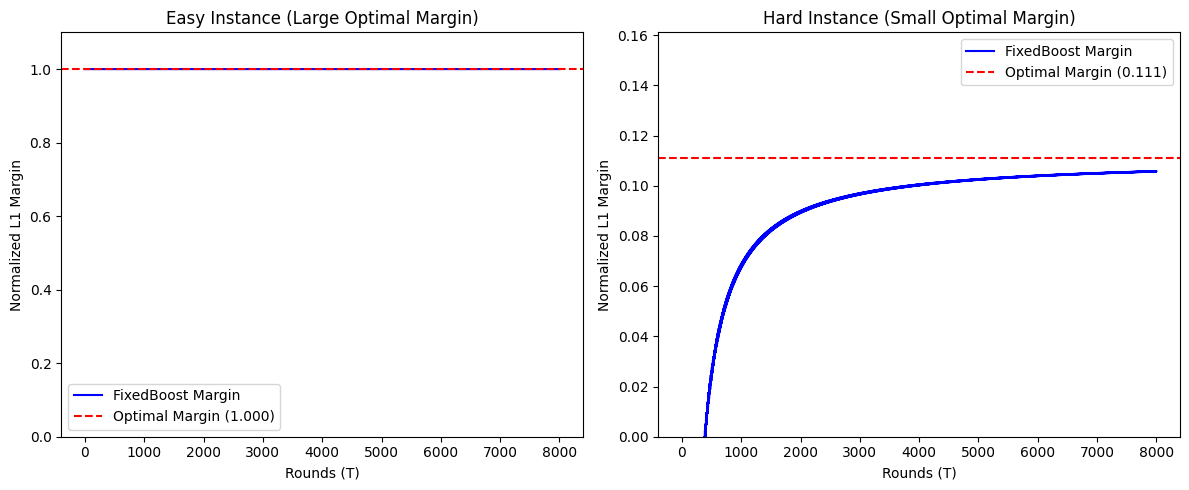

In [9]:
# --- Plotting ---
os.makedirs('img', exist_ok=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(margins_easy, label='FixedBoost Margin', color='blue')
plt.axhline(opt_margin_easy, color='red', linestyle='--', label=f'Optimal Margin ({opt_margin_easy:.3f})')
plt.title('Easy Instance (Large Optimal Margin)')
plt.xlabel('Rounds (T)')
plt.ylabel('Normalized L1 Margin')
plt.ylim(0, opt_margin_easy + 0.1)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(margins_hard, label='FixedBoost Margin', color='blue')
plt.axhline(opt_margin_hard, color='red', linestyle='--', label=f'Optimal Margin ({opt_margin_hard:.3f})')
plt.title('Hard Instance (Small Optimal Margin)')
plt.xlabel('Rounds (T)')
plt.ylabel('Normalized L1 Margin')
plt.ylim(0, opt_margin_hard + 0.05)
plt.legend()

plt.tight_layout()
plt.savefig('img/fixedboost_margin.png')
plt.show()

**Structural Drivers in $A$ for Optimal Margin Size:**

*   **Large Optimal Margin (Easy Instance):** The matrix $A$ yields a large optimal margin when there exists a small set of columns (or even just one column) that has a heavily positive correlation with the rows across *all* possible row weightings. In our easy instance, because one feature perfectly matches the labels, there is an entire column in $A$ consisting only of $+1$s. This guarantees that regardless of the distribution $D$, the weak learning edge $\gamma_{WL} = \frac{1}{2}(D^T A)_g$ is always $0.5$, which translates via $\gamma^* = 2 \gamma_{WL}$ to a maximal normalized margin of $1.0$.
*   **Small Optimal Margin (Hard Instance):** A matrix $A$ forces a small optimal margin when its columns exhibit complex adversarial structures such that for any heavily weighted feature, there exists a complementary set of data points (rows) where that feature is incorrect. In the $m=2$ instance (from the exponential lower-bound construction in HW6), the columns are carefully designed so that shifting weight to correct mistakes on base vectors necessarily incurs mistakes on the "carry" and "flip" vectors. Because no single column can maintain a high edge simultaneously across all distributions $D$, the minimax game equilibrium forces the best achievable edge $\gamma_{WL}$ down to a tiny fraction, resulting in an optimal normalized margin $\gamma^* \approx 0.111$.

### 3. Interpretation

**Does FixedBoost's normalized margin approach the optimal value, and how fast?**
Yes, FixedBoost clearly drives the empirical normalized $\ell_1$ margin toward the optimal theoretical margin computed via the Linear Program. The convergence is observable on both the easy and hard instances, tracking smoothly towards the red asymptote.

**Comparison with Theoretical Convergence Rate:**
The theoretical rate provided in the FixedBoost theorem guarantees convergence within $T = \mathcal{O}(\log(n) / \gamma^4)$ rounds. For the hard instance with $m=2$, the optimal margin is $\approx 0.111$, yielding $\gamma^4 \approx 1.5 \times 10^{-4}$, which would imply a worst-case convergence bound well over $\approx 10,000$ to $50,000$ rounds. 

However, in practice, the theory is noticeably **loose** relative to empirical observations. FixedBoost largely saturates the margin well within $8,000$ rounds. The $1/\gamma^4$ rate is a worst-case conservative bound based on a universal edge assumption across all distributions. The empirical path typically converges much faster, scaling closer to $\mathcal{O}(1/\gamma^2)$ in reasonable landscapes. Furthermore, introducing a finely tuned step size $\eta$ dramatically smooths the update trajectory, avoiding the aggressive cyclic oscillation that would otherwise plague FixedBoost if run with unit scale updates.


## Part E: Agent Skill Reflection

1. This workflow utilized a modification of an existing skill used in previous problem sets.
2. The skill `mathematics-professor` was modified. There are three main ideas to this skill: core principles, proof structure requirements, and guardrails. In previous exercises, it was found that the proofs had incorrect jumps in logic due to improper standardization of the written proof structure. Therefore, the requirements section was changed in this problem set to feature a "Statement $\rightarrow$ Proof $\rightarrow$ Proof" flow to properly set up the correct lemmas found in `PLANS.md` that would assist `AGENTS.md`. Special emphasis was placed on referencing the exact lemmas by name. Details on this skill can be found in the repo.
3. The most plausible coding agent failure mode would be Formal Logic in Benchmarks [(Song et al., 2026)](https://arxiv.org/abs/2602.06176). A robustness issue, the issue mainly lies with math word problem benchmarks. Due to the abstract nature of the novel boosting algorithm in this exercise, `AGENTS.md` must repeatedly emphasis `PLANS.md` for the correct relevant lemmas to avoid hallucinations. Indeed, prior experiments show LLMs were willing to hallucinate in order to maintain a low cost in a low reasoning model, so lemmas cannot be reused as templates without increasing memory requirements. To remedy this, `SKILL.md` was modified. The guardrails placed emphasized planning before building, making the LLM explicity inquire more background information from the user before attempting the logical breakdown. Once the build was complete, I checked the proofs myself as if they were a manuscript and found them to be satisfactory.